In [1]:
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import numpy as np
import corner
from copy import deepcopy
from matplotlib import gridspec
import glob
from tqdm import tqdm
from scipy.stats import dirichlet
import seaborn as sns
from emcee.autocorr import integrated_time


## Try GR stat with 1 output file

In [2]:
result_file='prod_retrainedCE/output_seed12.hdf5'
flow_file = h5py.File(result_file, 'r')
branching_fracs = np.array(flow_file['model_selection']['samples']['block0_values'])

In [3]:
branching_fracs.shape

(150000, 7)

In [4]:
Nwalkers=250
chain_length = branching_fracs.shape[0]/Nwalkers

In [5]:
chain_length

600.0

In [6]:
indv_chains = np.reshape(branching_fracs, (-1,int(chain_length),7))

In [7]:
indv_chains.shape

(250, 600, 7)

In [8]:
mean_chain = np.mean(indv_chains, axis=1)
mean_of_means = np.mean(mean_chain, axis=0)
variance_of_means = (chain_length/(Nwalkers-1))*np.sum((mean_chain-mean_of_means)**2, axis=0)
ave_variance = np.mean((1/(chain_length-1))*np.sum((indv_chains-mean_chain[:,None,:])**2, axis=1), axis=0)
GRstat = (((((chain_length-1)/chain_length)*ave_variance)+((1/chain_length)*variance_of_means)))/ave_variance

In [9]:
GRstat

array([1.53072229, 1.26740796, 1.2458096 , 1.20046613, 1.38271577,
       1.23393405, 1.25185338])

## GR stat with original DR output files combined

In [5]:
result_files=glob.glob('../prod_retrainedCE/output_seed*.hdf5')
GRstat=[]
for result_file in result_files:
    print(result_file)
    flow_file = h5py.File(result_file, 'r')
    branching_fracs = np.array(flow_file['model_selection']['samples']['block0_values'])
    indv_chains = np.reshape(branching_fracs, (-1,int(chain_length),7))
    mean_chain = np.mean(indv_chains, axis=1)
    mean_of_means = np.mean(mean_chain, axis=0)
    variance_of_means = (chain_length/(Nwalkers-1))*np.sum((mean_chain-mean_of_means)**2, axis=0)
    ave_variance = np.mean((1/(chain_length-1))*np.sum((indv_chains-mean_chain[:,None,:])**2, axis=1), axis=0)
    GRstat.append((((((chain_length-1)/chain_length)*ave_variance)+((1/chain_length)*variance_of_means)))/ave_variance)

../prod_retrainedCE/output_seed27.hdf5
../prod_retrainedCE/output_seed12.hdf5
../prod_retrainedCE/output_seed94.hdf5
../prod_retrainedCE/output_seed56.hdf5
../prod_retrainedCE/output_seed39.hdf5


In [8]:
branching_fracs.shape

(150000, 7)

In [6]:
GRstat

[array([1.51227284, 1.26911325, 1.20867577, 1.23738554, 1.32589133,
        1.26254033, 1.20980266]),
 array([1.53072229, 1.26740796, 1.2458096 , 1.20046613, 1.38271577,
        1.23393405, 1.25185338]),
 array([1.50505586, 1.26610847, 1.25115192, 1.26964243, 1.34843958,
        1.23966537, 1.26420985]),
 array([1.51497496, 1.2851064 , 1.24603127, 1.26709954, 1.3617859 ,
        1.23186758, 1.25640186]),
 array([1.64268889, 1.29524012, 1.25073769, 1.3009515 , 1.34458124,
        1.22150272, 1.29044857])]

In [11]:
np.mean(GRstat, axis=0)

array([1.54114297, 1.27659524, 1.24048125, 1.25510903, 1.35268277,
       1.23790201, 1.25454326])

## Multiple output files, downsampling the chains

In [22]:
result_files=glob.glob('../prod_retrainedCE/output_seed*.hdf5')
GRstat=[]
down_chain_length = chain_length/10
for result_file in result_files:
    print(result_file)
    flow_file = h5py.File(result_file, 'r')
    branching_fracs = np.array(flow_file['model_selection']['samples']['block0_values'])
    indv_chains = np.reshape(branching_fracs, (-1,int(chain_length),7))
    downsamp_chains = indv_chains[:,::10,:]
    mean_chain = np.mean(downsamp_chains, axis=1)
    mean_of_means = np.mean(mean_chain, axis=0)
    variance_of_means = (down_chain_length/(Nwalkers-1))*np.sum((mean_chain-mean_of_means)**2, axis=0)
    ave_variance = np.mean((1/(down_chain_length-1))*np.sum((downsamp_chains-mean_chain[:,None,:])**2, axis=1), axis=0)
    GRstat.append((((((down_chain_length-1)/down_chain_length)*ave_variance)+((1/down_chain_length)*variance_of_means)))/ave_variance)

../prod_retrainedCE/output_seed27.hdf5
../prod_retrainedCE/output_seed12.hdf5
../prod_retrainedCE/output_seed94.hdf5
../prod_retrainedCE/output_seed56.hdf5
../prod_retrainedCE/output_seed39.hdf5


In [31]:
downsamp_chains.shape

(250, 60, 7)

In [24]:
np.mean(GRstat, axis=0)

array([1.5184559 , 1.25761258, 1.22229194, 1.23720667, 1.33080252,
       1.22046575, 1.23765571])

In [10]:
np.swapaxes(indv_chains,0,1).shape

(3000, 250, 7)

In [10]:
from emcee.autocorr import integrated_time

integrated_time(np.swapaxes(indv_chains,0,1))

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [129.76271242  90.33698796  85.89754852  84.18218316  97.12921518
  88.03731359  86.15994696]

## Old plus new runs, autocorrelation time

'mean_chain = np.mean(indv_chains, axis=1)\nmean_of_means = np.mean(mean_chain, axis=0)\nvariance_of_means = (chain_length/(Nwalkers-1))*np.sum((mean_chain-mean_of_means)**2, axis=0)\nave_variance = np.mean((1/(chain_length-1))*np.sum((indv_chains-mean_chain[:,None,:])**2, axis=1), axis=0)\nGRstat.append((((((chain_length-1)/chain_length)*ave_variance)+((1/chain_length)*variance_of_means)))/ave_variance)'

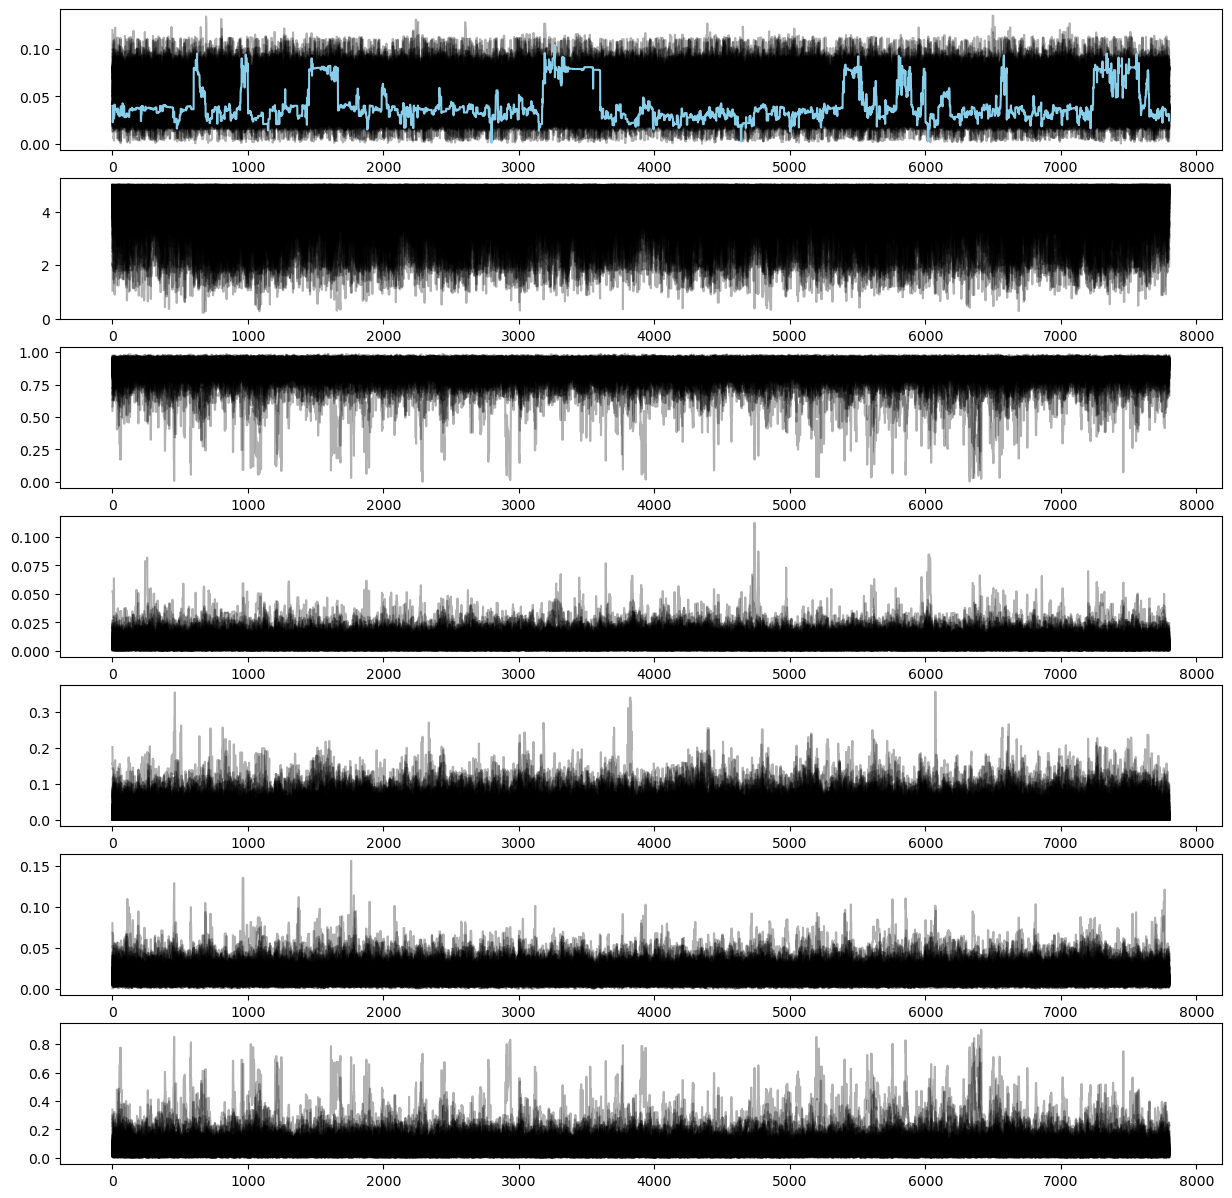

In [84]:
#try adding runs together?
result_files=glob.glob('prod_retrainedCE/output_seed*.hdf5') + glob.glob('prod_longsampling/*.hdf5')
GRstat=[]
samples_allchains = np.array([])

for result_file in result_files:
    flow_file = h5py.File(result_file, 'r')
    branching_fracs = np.array(flow_file['model_selection']['samples']['block0_values'])
    samples_allchains = np.append(samples_allchains, branching_fracs)

indv_chains = np.reshape(samples_allchains, (-1,int(chain_length*len(result_files)),7))
plt.rcParams["figure.figsize"] = (15,15)
fig, axes = plt.subplots(7,1)

for i,ax in enumerate(axes):
    for walker in range(250):
        ax.plot(indv_chains[walker,:,i], color='black', alpha=0.3)
axes[0].plot(indv_chains[4,:,0], color='skyblue')

"""mean_chain = np.mean(indv_chains, axis=1)
mean_of_means = np.mean(mean_chain, axis=0)
variance_of_means = (chain_length/(Nwalkers-1))*np.sum((mean_chain-mean_of_means)**2, axis=0)
ave_variance = np.mean((1/(chain_length-1))*np.sum((indv_chains-mean_chain[:,None,:])**2, axis=1), axis=0)
GRstat.append((((((chain_length-1)/chain_length)*ave_variance)+((1/chain_length)*variance_of_means)))/ave_variance)"""

In [ ]:
integrated_time(np.swapaxes(indv_chains,0,1))

'mean_chain = np.mean(indv_chains, axis=1)\nmean_of_means = np.mean(mean_chain, axis=0)\nvariance_of_means = (chain_length/(Nwalkers-1))*np.sum((mean_chain-mean_of_means)**2, axis=0)\nave_variance = np.mean((1/(chain_length-1))*np.sum((indv_chains-mean_chain[:,None,:])**2, axis=1), axis=0)\nGRstat.append((((((chain_length-1)/chain_length)*ave_variance)+((1/chain_length)*variance_of_means)))/ave_variance)'

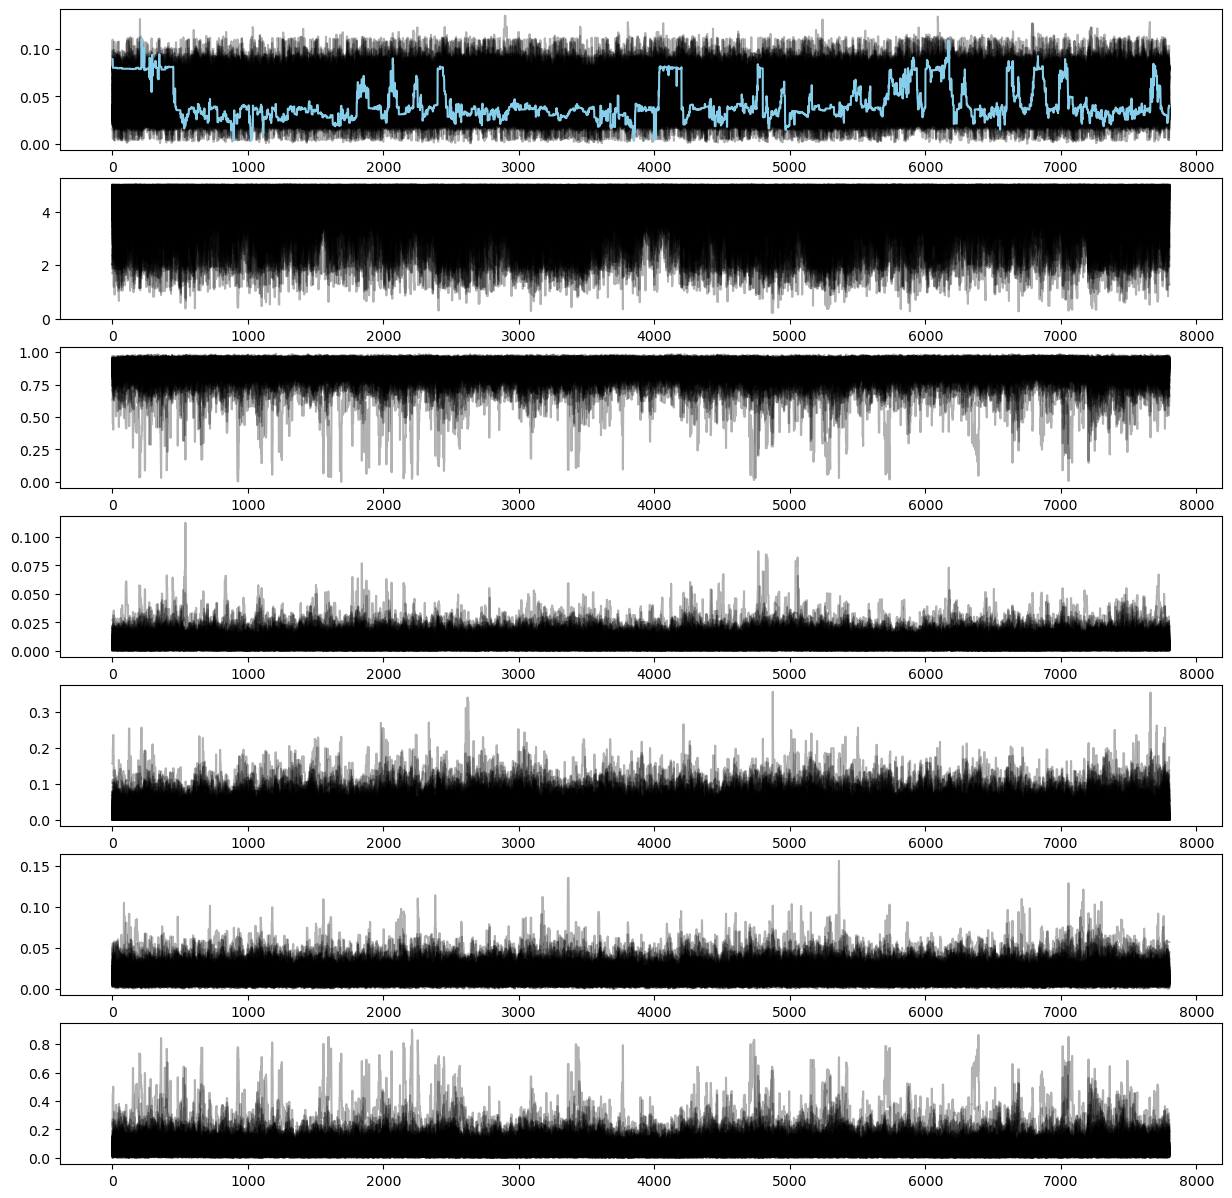

In [88]:
#try adding runs together? - this should be the correct reshaping of the array
result_files=glob.glob('prod_retrainedCE/output_seed*.hdf5') + glob.glob('prod_longsampling/*.hdf5')
GRstat=[]
samples_allchains = np.zeros((int(chain_length*len(result_files)),Nwalkers,7))

for ridx,result_file in enumerate(result_files):
    flow_file = h5py.File(result_file, 'r')
    branching_fracs = np.array(flow_file['model_selection']['samples']['block0_values'])
    indv_chains = np.reshape(branching_fracs, (-1,int(chain_length),7))
    samples_allchains[int(chain_length*ridx):int(chain_length*(ridx+1)),:,:] = np.swapaxes(indv_chains,0,1)

#indv_chains = np.reshape(samples_allchains, (int(chain_length*len(result_files)),-1,7))
plt.rcParams["figure.figsize"] = (15,15)
fig, axes = plt.subplots(7,1)

for i,ax in enumerate(axes):
    for walker in range(250):
        ax.plot(samples_allchains[:,walker,i], color='black', alpha=0.3)
axes[0].plot(samples_allchains[:,4,0], color='skyblue')

"""mean_chain = np.mean(indv_chains, axis=1)
mean_of_means = np.mean(mean_chain, axis=0)
variance_of_means = (chain_length/(Nwalkers-1))*np.sum((mean_chain-mean_of_means)**2, axis=0)
ave_variance = np.mean((1/(chain_length-1))*np.sum((indv_chains-mean_chain[:,None,:])**2, axis=1), axis=0)
GRstat.append((((((chain_length-1)/chain_length)*ave_variance)+((1/chain_length)*variance_of_means)))/ave_variance)"""

In [89]:
integrated_time(samples_allchains)

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 156;
tau: [168.98978134 115.81847483 108.7293143  109.1084667  123.3333349
 102.60425637 110.45623241]

## GR stat with old and new results, only one walker from each file

In [91]:
result_files=glob.glob('prod_retrainedCE/output_seed*.hdf5') + glob.glob('prod_longsampling/*.hdf5')
GRstat=[]
samples_allchains = np.zeros((Nwalkers,int(chain_length),len(result_files),7))

for ridx,result_file in enumerate(result_files):
    flow_file = h5py.File(result_file, 'r')
    branching_fracs = np.array(flow_file['model_selection']['samples']['block0_values'])
    indv_chains = np.reshape(branching_fracs, (-1,int(chain_length),7))
    samples_allchains[:,:,ridx,:] = indv_chains

#samples_allchains = np.reshape(samples_allchains, (-1,int(chain_length),len(result_files),7))
print(samples_allchains.shape)

for walker in range(Nwalkers):
    indv_chains = np.swapaxes(samples_allchains[walker,:,:,:],0,1)
    mean_chain = np.mean(indv_chains, axis=1)
    mean_of_means = np.mean(mean_chain, axis=0)
    variance_of_means = (chain_length/(Nwalkers-1))*np.sum((mean_chain-mean_of_means)**2, axis=0)
    ave_variance = np.mean((1/(chain_length-1))*np.sum((indv_chains-mean_chain[:,None,:])**2, axis=1), axis=0)
    GRstat.append((((((chain_length-1)/chain_length)*ave_variance)+((1/chain_length)*variance_of_means)))/ave_variance)

(250, 600, 13, 7)


In [93]:
np.mean(GRstat, axis=0)

array([1.02746336, 1.01307218, 1.01128955, 1.0110326 , 1.01503535,
       1.01033769, 1.01156154])